Step 1 -  Importation of needed libraries and declaration of training variables     

In [29]:
import numpy as np
import matplotlib.pyplot as plt 

In [30]:
x_train = np.array([1.0,2.0])
y_train = np.array([300.0,500.0])

Visualizing of Training Data points

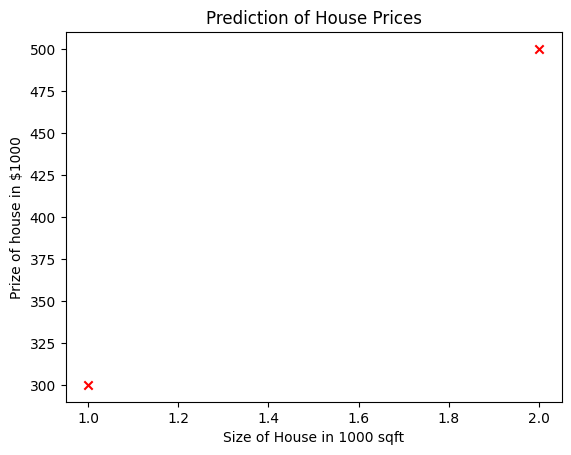

In [31]:
plt.scatter(x=x_train,y=y_train,c='r',marker='x')
plt.xlabel("Size of House in 1000 sqft")
plt.ylabel("Prize of house in $1000")
plt.title("Prediction of House Prices")
plt.show()

Writing the cost function i.e the mean squared error

In [32]:
def compute_cost(x,y,w,b):
    """
    Calculates the cost for all the data points

    Args:
    x = input training points
    y = target variables
    w,b = parameters of the linear model 
    
    Returns total cost
    """
    cost = 0
    cost_sum = 0
    m = x.shape[0]
    for i in range(m):
        y_hat = w * x[i] + b
        cost = (y_hat - y[i])**2
        cost_sum += cost
    total_cost = (1/2*m) * cost_sum
    return total_cost   

Writing the function for computing the gradient

In [33]:
def compute_gradient(x,y,w,b):
    """
    Computes the gradient w.r.t parameter w and w.r.t parameter b

    Returns the derivatives that are used in the gradient descent algorithms
    i.e dj_dw, dj_db
    """
    dj_dw_tmp = 0
    dj_db_tmp = 0
    dj_dw = 0
    dj_db = 0
    m = x.shape[0]
    for i in range(m):
        y_hat = w * x[i] + b
        dj_dw_tmp = (y_hat - y[i]) * x[i]
        dj_db_tmp = (y_hat - y[i])
        dj_dw += dj_dw_tmp
        dj_db += dj_db_tmp
    dj_dw = (1/m) * dj_dw
    dj_db = (1/m) * dj_db

    return dj_dw, dj_db

Writing the gradient descent function

In [34]:
def gradient_descent(x,y,w_init,b_init,num_iters,alpha,cost_function,gradient_function):
    """
    
    """
    j_hist = []
    p_hist = []
    w = w_init
    b = b_init

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x,y,w,b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        j_hist.append(cost_function(x,y,w,b))
        p_hist.append([w,b])
        

    return w,b,j_hist, p_hist

In [35]:
w_init = 0
b_init = 0
num_iters = 10000
alpha = 0.01

w,b,j_hist,p_hist=gradient_descent(x_train,y_train,w_init,b_init,num_iters,alpha,compute_cost,compute_gradient)

min_cost_index = j_hist.index(min(j_hist))
print(f"Cost: {min(j_hist)} ---> Params: {p_hist[min_cost_index]}")

Cost: 2.698005865032158e-05 ---> Params: [np.float64(199.99285075131766), np.float64(100.011567727362)]


From our model, w= 199.99285075131766, b=100.011567727362

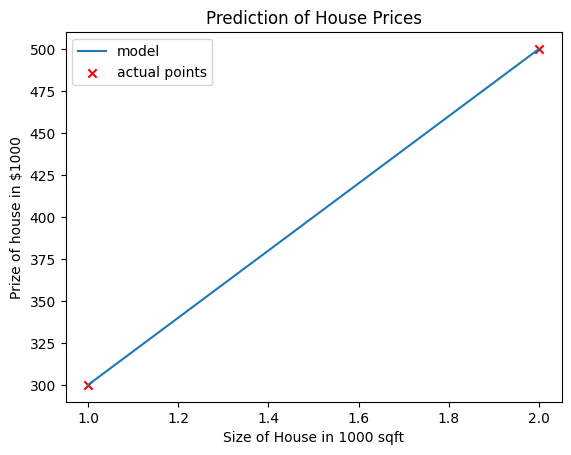

In [38]:
x=x_train
m = x.shape[0]
w= 199.99285075131766
b=100.011567727362
f_wb = np.zeros(m)
for i in range(m):
    f_wb[i] = w* x[i] + b

plt.plot(x_train,f_wb,label="model")
plt.scatter(x=x_train,y=y_train,c='r',marker='x',label="actual points")
plt.xlabel("Size of House in 1000 sqft")
plt.ylabel("Prize of house in $1000")
plt.title("Prediction of House Prices")
plt.legend()
plt.show()
